In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [18]:
data = load_breast_cancer()


In [19]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target


In [20]:

print(df.head())


   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [21]:
#preprocessing data
X = df.drop('target', axis=1)
y = df['target']

In [22]:
# Scaling (optional but good practice)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


In [24]:
#  Decision Tree

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("\n===== Decision Tree =====")
print(classification_report(y_test, y_pred_dt))



===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



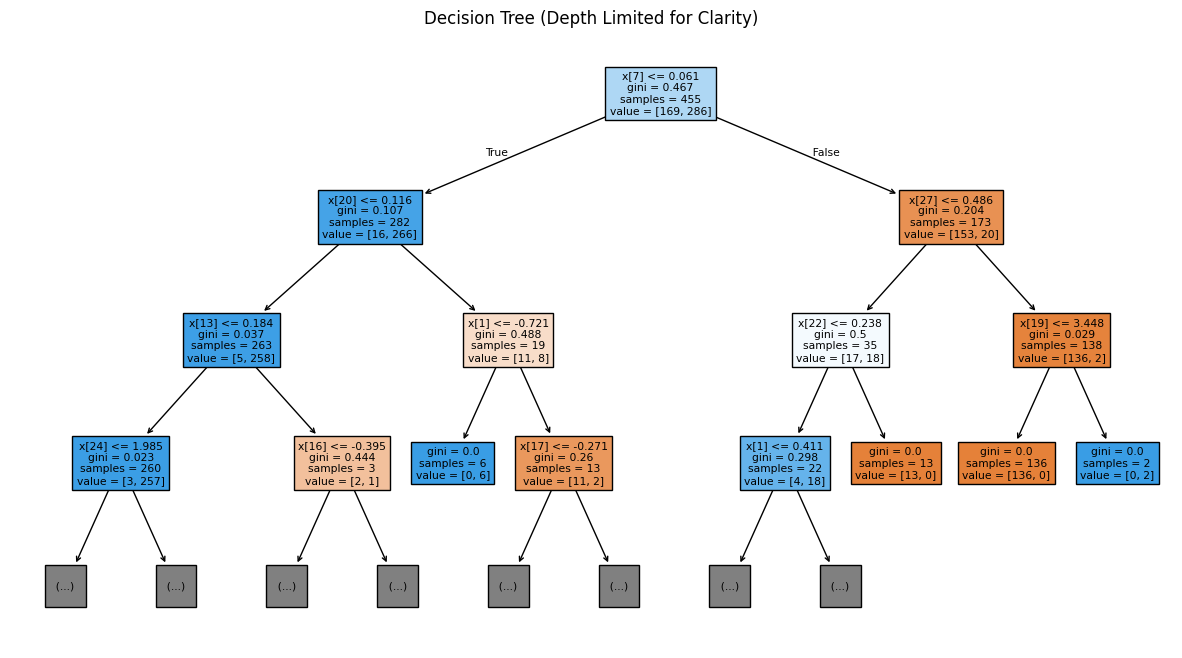

In [25]:
#  Visualize Decision Tree

plt.figure(figsize=(15,8))
plot_tree(dt_model, filled=True, max_depth=3)
plt.title("Decision Tree (Depth Limited for Clarity)")
plt.show()

In [26]:
#  Random Forest

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("\n===== Random Forest =====")
print(classification_report(y_test, y_pred_rf))


===== Random Forest =====
              precision    recall  f1-score   support

           0       0.98      0.93      0.95        43
           1       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [27]:
#  Model Comparison

acc_dt = accuracy_score(y_test, y_pred_dt)
acc_rf = accuracy_score(y_test, y_pred_rf)

print("\nDecision Tree Accuracy:", acc_dt)
print("Random Forest Accuracy:", acc_rf)


Decision Tree Accuracy: 0.9473684210526315
Random Forest Accuracy: 0.9649122807017544


In [28]:
#  Feature Importance
importance = rf_model.feature_importances_

In [29]:
# Sort features
indices = np.argsort(importance)

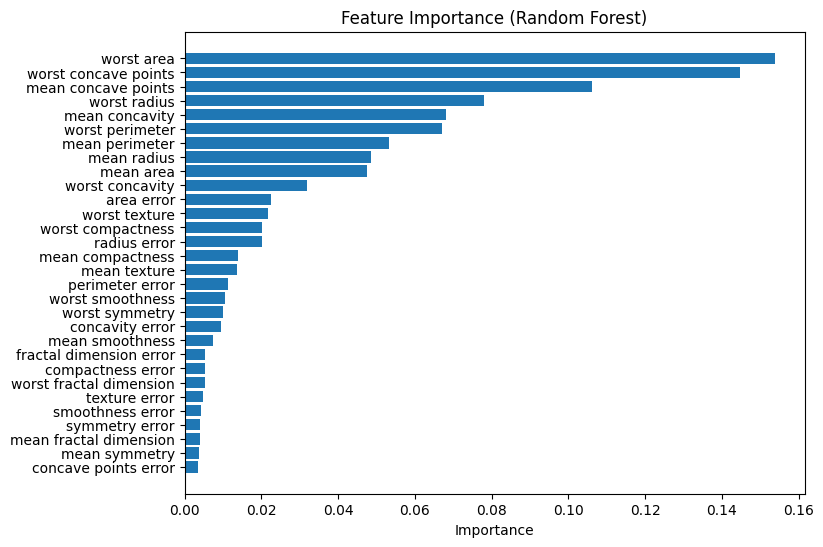

In [30]:
plt.figure(figsize=(8,6))
plt.barh(range(len(indices)), importance[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.show()

In [ ]:
'''
Final Outcome
Built classification models on medical dataset
Compared Decision Tree vs Random Forest
Observed:
Random Forest usually gives better accuracy
Decision Tree is more interpretable
Identified most important features  
'''